In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
from google.colab import files
uploaded = files.upload()

Saving cairo weather.csv to cairo weather (1).csv


In [13]:
df = pd.read_csv(list(uploaded.keys())[0])
df.head()

,time,temperature,temperature_min (°C),temperature_max (°C)
0,2/1/2009,14.1,7.9,20.6
1,2/2/2009,14.3,5.8,21.9
2,2/3/2009,16.1,9.2,24.0
3,2/4/2009,17.9,10.9,26.8
4,2/5/2009,18.0,11.4,26.4


In [14]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5813 entries, 0 to 5812
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   time                  5813 non-null   object 
 1   temperature           5813 non-null   float64
 2   temperature_min (°C)  5813 non-null   float64
 3   temperature_max (°C)  5813 non-null   float64
dtypes: float64(3), object(1)
memory usage: 181.8+ KB


,temperature,temperature_min (°C),temperature_max (°C)
count,5813.000000,5813.000000,5813.000000
mean,23.067590,16.747979,29.668708
std,6.244698,5.501338,7.089923
min,8.600000,3.300000,11.200000
25%,17.400000,12.000000,23.400000
50%,23.700000,17.200000,30.600000
75%,28.600000,21.500000,35.900000
max,37.400000,31.900000,45.400000


In [15]:
df['time'] = pd.to_datetime(df['time'])

In [16]:
df['year'] = df['time'].dt.year
df['month'] = df['time'].dt.month
df[['time', 'year', 'month']].head()

,time,year,month
0,2009-02-01,2009,2
1,2009-02-02,2009,2
2,2009-02-03,2009,2
3,2009-02-04,2009,2
4,2009-02-05,2009,2


In [17]:
df.isnull().sum()
df = df.dropna()

In [18]:
yearly_temp = df.groupby('year')['temperature'].mean().reset_index()
yearly_temp

,year,temperature
0,2009,22.940120
1,2010,23.224110
2,2011,21.534247
3,2012,22.311475
4,2013,22.281918
5,2014,22.629863
6,2015,22.479178
7,2016,22.925410
8,2017,22.881370
9,2018,23.857808


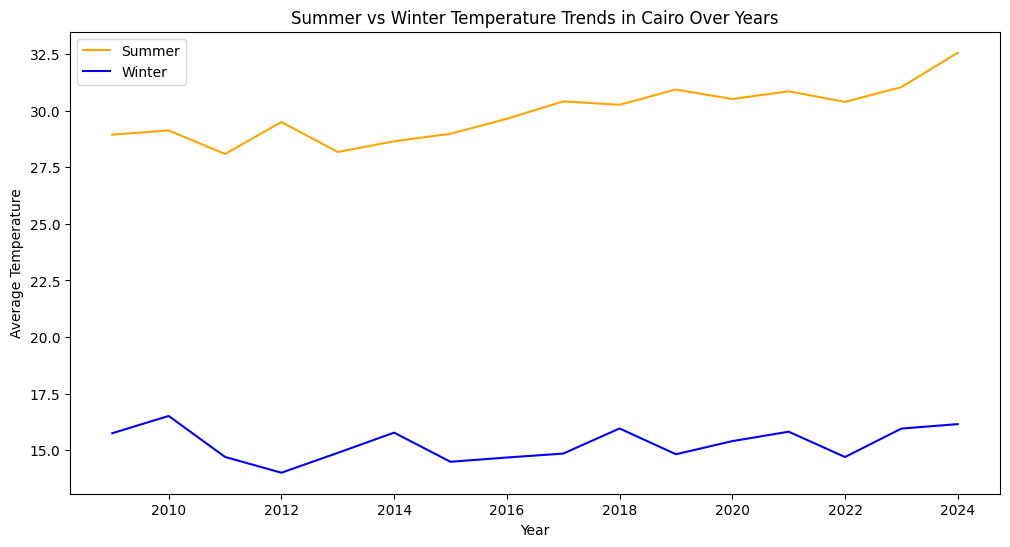

In [19]:
def get_season(month):
  if month in [6, 7, 8]:
    return "Summer"
  elif month in [12, 1, 2]:
    return "Winter"
  else:
    return None

df['season'] = df['month'].apply(get_season)

season_df = df[df['season'].notna()]
season_trend = season_df.groupby(['year', 'season'])['temperature'].mean().reset_index()

plt.figure(figsize = (12,6))

sns.lineplot(data = season_trend[season_trend['season'] == 'Summer'],
             x = 'year', y = 'temperature', label = 'Summer', color = 'orange')

sns.lineplot(data = season_trend[season_trend['season'] == 'Winter'],
             x = 'year', y = 'temperature', label = 'Winter', color = 'blue')

plt.title('Summer vs Winter Temperature Trends in Cairo Over Years')
plt.xlabel('Year')
plt.ylabel('Average Temperature')
plt.legend()
plt.show()

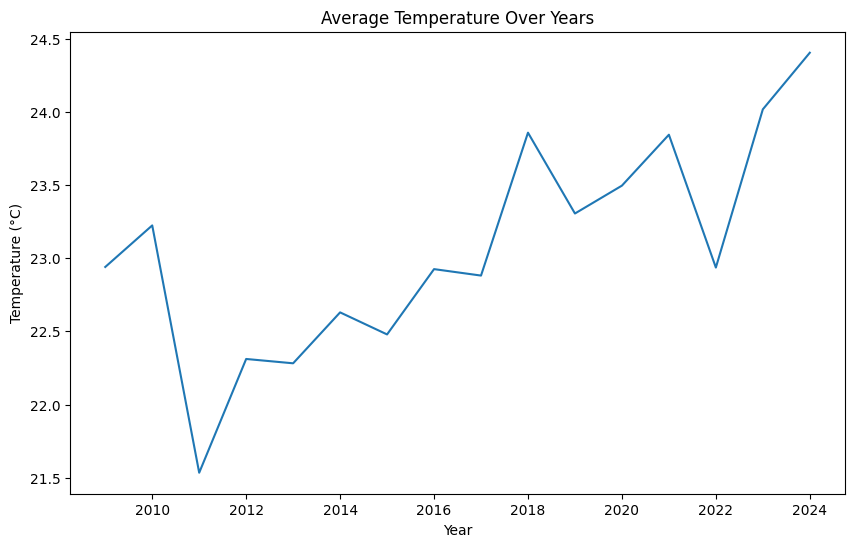

In [20]:
plt.figure(figsize = (10,6))
sns.lineplot(data = yearly_temp, x = 'year', y = 'temperature')
plt.title('Average Temperature Over Years')
plt.xlabel('Year')
plt.ylabel('Temperature (°C)')
plt.show()

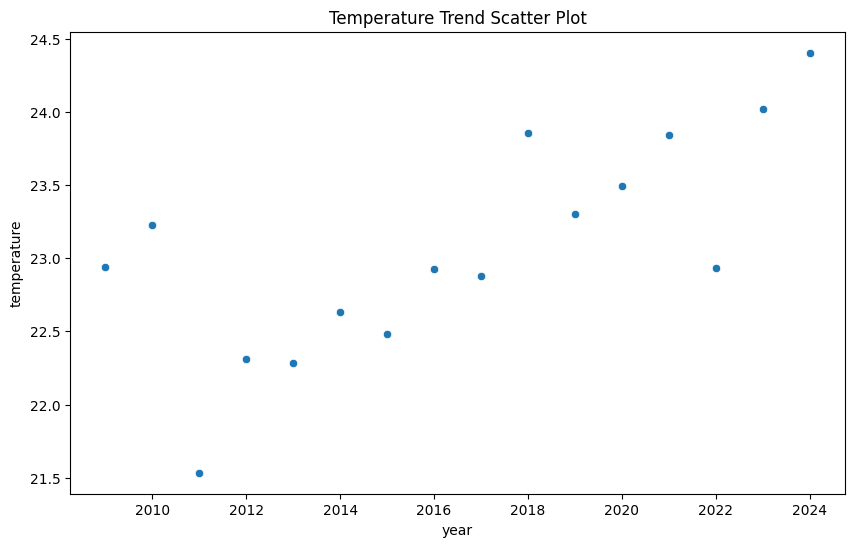

In [21]:
plt.figure(figsize = (10,6))
sns.scatterplot(data = yearly_temp, x = 'year', y = 'temperature')
plt.title("Temperature Trend Scatter Plot")
plt.show()

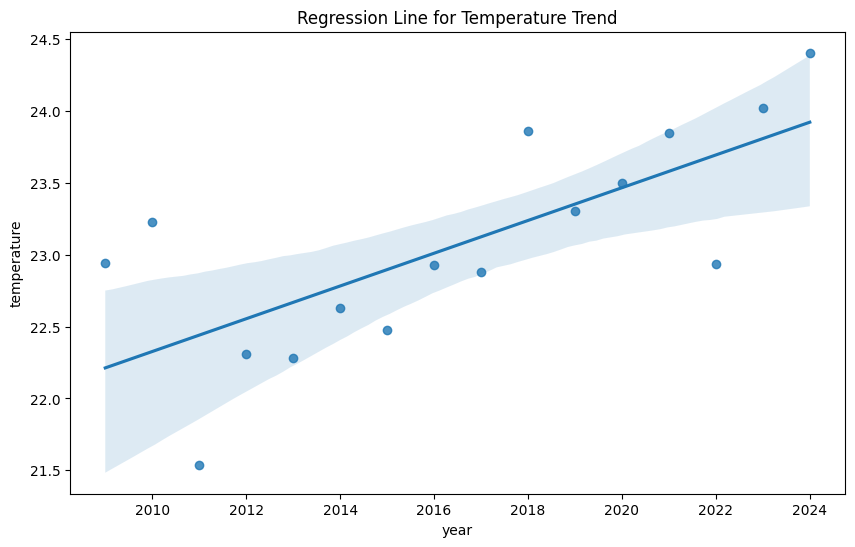

In [22]:
plt.figure(figsize = (10,6))
sns.regplot(data = yearly_temp, x = 'year', y = 'temperature')
plt.title("Regression Line for Temperature Trend")
plt.show()

H0: There is no significant trend in temperature over the years in Cairo  
H1: There is a significant trend in temperature over the years in Cairo

In [23]:
correlation = yearly_temp['year'].corr(yearly_temp['temperature'])
correlation

np.float64(0.7269695007977757)

In [24]:
from scipy.stats import linregress

result = linregress(yearly_temp['year'], yearly_temp['temperature'])

print("Slope: ", result.slope)
print("P-value: ", result.pvalue)

Slope:  0.11389822809434559
P-value:  0.00142002941034978


In [25]:
alpha = 0.05

if result.pvalue < alpha:
    print("Reject H0, There is a significant trend in temperature over the years in Cairo")

else:
  print("Fail to reject H0, There is no significant trend in temperature over the years in Cairo")

Reject H0, There is a significant trend in temperature over the years in Cairo


Based on the statistical analysis and visualizations, we reject to reject the null hypothesis.
This indicates that temperature in Cairo has shown a significant trend over the years.